In [2]:
import ast
import rich
import json

In [3]:
with open('intent_human_movement_with_negoeval_v2.jsonl') as f:
    actual = [json.loads(i) for i in f.readlines()]
    
countries_list = ['Austria', 'England', 'France', 'Germany', 'Italy', 'Russia', 'Turkey']

In [4]:
actual[0]

{'game_id': '101921',
 'phase_name': 'S1903M',
 'env_uuid': '01JN071FEATXC1XA1EYB5S0RAK',
 'Turkey_original_predict': 'A BUL SEV VIA; A GRE H; A SEV UKR; F BLA C A BUL SEV; F ION S F TYS TUN; F SMY AEG',
 'Austria_original_predict': 'A BUD GAL; A GAL WAR; A SER BUD; A RUM S A SEV UKR; A VEN ROM; A VIE S A BUD GAL; F TUN TYS; F VEN APU; F TYS NAP',
 'Turkey_units': 'ANK, CON, SMY, BUL, GRE, SEV',
 'Austria_units': None,
 'intent_dialogue': '0 AUSTRIA -> TURKEY: Interesting he gets rid of fleet in GOB.....\nIm going to hit GALICIA this move with Vienna and Budapest. We also need to hit Ukraine. I can support SEV to UKR from Rum. Only prob with that is it doesn\'t give your army a way out via Rumania unless you convoy.....which i think is the best move. So my orders (unless u disagree) are;\nBUD to GAL\nVIE support Bud to GAL\nRUM support SEV to UKR\nSER to TRI\nTYR to VEN\nVEN to APU\r\n1 AUSTRIA -> TURKEY: Next move we should also consider Greece to Naples. Although this means i lose 1 

In [5]:
def get_score_with_env_new(countries, record):

    score_dict = {}
    
    # 1. env
    score_dict['env'] = record.get('env_uuid', None)
    
    # 2. 当前记录里实际出现了哪些国家
    score_dict['countries'] = countries
    
    # 3. negoeval 来源
    # 注意：negoeval 数据在 'evaluation' 字段中
    evaluation_result = record.get('evaluation', {})

    for c in countries:
        # === (1) taskeval_score ===
        #    在原始数据里形如 record['Austria']['AUSTRIA'] = ['AUSTRIA', -0.0369]
        try:
            score_dict[f"{c}_taskeval_score"] = record[c][c.upper()][1]
        except (KeyError, IndexError, TypeError):
            score_dict[f"{c}_taskeval_score"] = None

        # === (2) negoeval_score ===
        #    原始数据: evaluation_result['AUSTRIA'] = {
        #        'overall_score': 5.0,
        #        'detailed_scores': {'ethos':5.0, 'logos':4.0, 'pathos':6.0}
        #    }
        #    注意：evaluation_result 中的键是大写的国家名
        nego_info = evaluation_result.get(c.upper())
        if nego_info:
            # 拿到 overall_score
            overall_score = nego_info.get('overall_score', None)
            # 拿到 detailed_scores
            ds = nego_info.get('detailed_scores', {})
            
            # 构造新字典
            flattened_dict = {
                'overall_score': overall_score,
                'ethos': ds.get('ethos', None),
                'logos': ds.get('logos', None),
                'pathos': ds.get('pathos', None)
            }
            score_dict[f"{c}_negoeval_score"] = flattened_dict
        else:
            score_dict[f"{c}_negoeval_score"] = None

    return score_dict


def get_score_dict_from_dialogue_new(dialogue, countries_list):
    """
    批量处理整个 dialogue (即每行 JSON 组成的列表)
    并返回包含评分信息的列表。
    """
    not_found_count = 0
    empty_predict_count = 0
    score_list = []
    
    for item in dialogue:
        # 根据需要过滤 intent_dialogue 为空的情况
        if not item.get('intent_dialogue'):
            continue
        
        # 找出该条中实际有哪些国家
        keys = [k for k in item.keys() if k in countries_list]
        
        # 过滤掉 '{country}_original_predict' 为空的情况
        valid_countries = []
        for country in keys:
            predict_key = f"{country}_original_predict"
            if predict_key in item and item[predict_key] != "":
                valid_countries.append(country)
            else:
                empty_predict_count += 1
        
        # 如果没有有效的国家，则跳过此条记录
        if valid_countries == []:
            continue
        
        # 获取评分
        env_score = get_score_with_env_new(valid_countries, item)
        if env_score is not None:
            score_list.append(env_score)
        else:
            not_found_count += 1

    print(f"Not found count: {not_found_count}")
    print(f"Empty predict count: {empty_predict_count}")
    return score_list

# def extract_quality(text):
#     """
#     Extract the value between <quality> and </quality> tags from a text.
    
#     Args:
#         text (str): The text containing quality tags
        
#     Returns:
#         bool or None: The extracted quality value (True/False) or None if not found
#     """
#     if not text:
#         return None
    
#     import re
#     pattern = r'<quality>\s*(True|False)\s*</quality>'
#     match = re.search(pattern, text, re.IGNORECASE)
    
#     if match:
#         quality_value = match.group(1)
#         return True if quality_value == "True" else False
    
#     return None

# Add quality extraction to the records
# for record in actual:
#     whether_negotiate = record.get('whether_negotiate', '')
#     record['quality'] = extract_quality(whether_negotiate)


In [74]:
# high_quality_records = [record for record in actual if record['quality']]

In [75]:
# record = []
# for i in high_quality_records:
#     record.append(i['env_uuid'])

In [6]:
score_actual = get_score_dict_from_dialogue_new(actual, countries_list)
# score_high_quality_records = get_score_dict_from_dialogue_new(high_quality_records, countries_list)

Not found count: 0
Empty predict count: 330


In [7]:
len(score_actual)

161

In [78]:
score_actual[0]

{'env': '01JN071FEATXC1XA1EYB5S0RAK',
 'countries': ['Turkey', 'Austria'],
 'Turkey_taskeval_score': -0.07786980271339417,
 'Turkey_negoeval_score': {'overall_score': 5.333333333333333,
  'ethos': 6.0,
  'logos': 5.0,
  'pathos': 5.0},
 'Austria_taskeval_score': 0.14926575124263763,
 'Austria_negoeval_score': {'overall_score': 5.0,
  'ethos': 5.0,
  'logos': 4.0,
  'pathos': 6.0}}

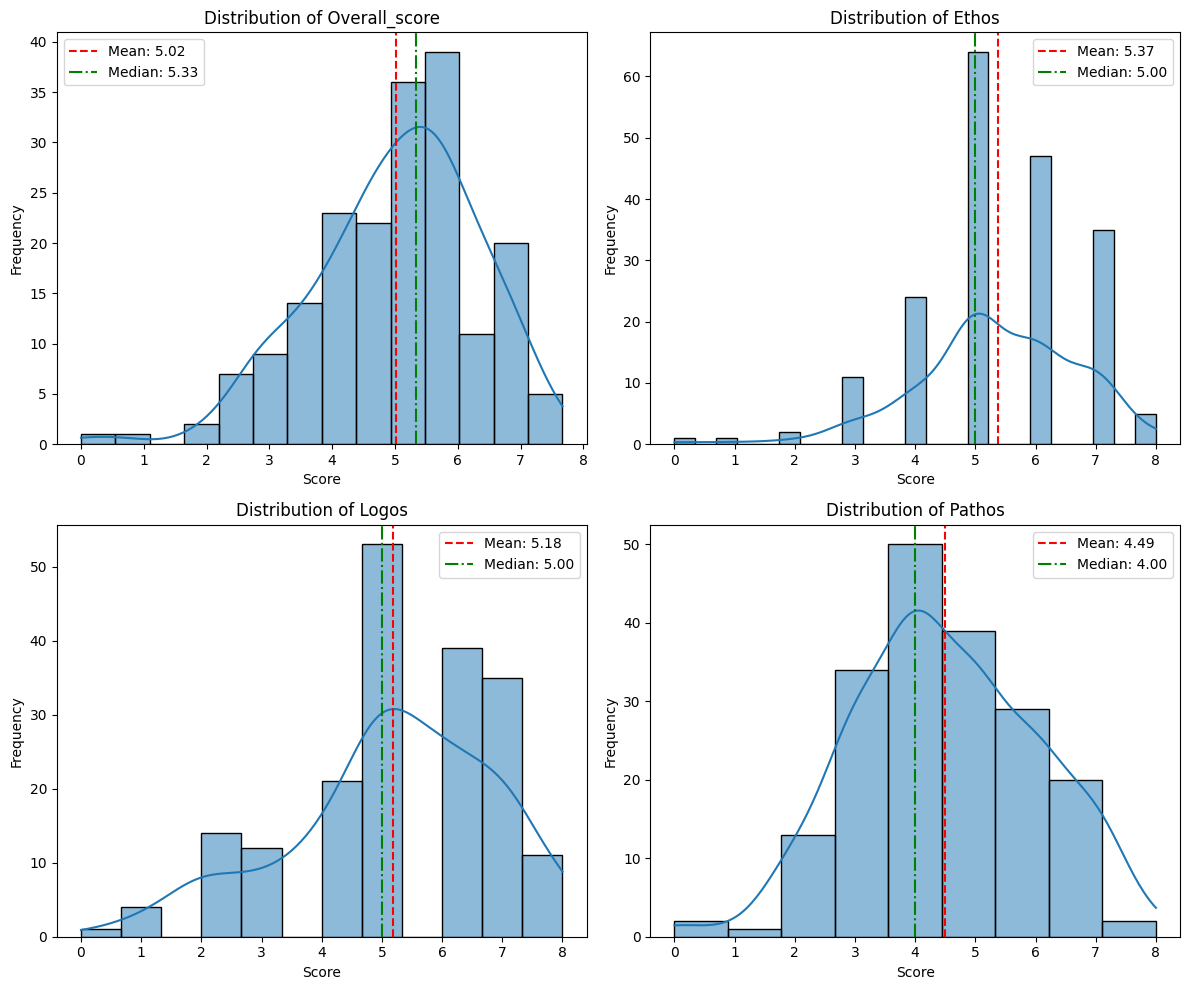

Summary Statistics:

Overall_score:
  Count: 190
  Mean: 5.02
  Median: 5.33
  Min: 0.00
  Max: 7.67
  Standard Deviation: 1.31

Ethos:
  Count: 190
  Mean: 5.37
  Median: 5.00
  Min: 0.00
  Max: 8.00
  Standard Deviation: 1.32

Logos:
  Count: 190
  Mean: 5.18
  Median: 5.00
  Min: 0.00
  Max: 8.00
  Standard Deviation: 1.71

Pathos:
  Count: 190
  Mean: 4.49
  Median: 4.00
  Min: 0.00
  Max: 8.00
  Standard Deviation: 1.53


In [79]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Extract negoeval scores for analysis
negoeval_scores = {
    'overall_score': [],
    'ethos': [],
    'logos': [],
    'pathos': []
}

# Collect all scores from each country in each dialogue
for entry in score_actual:
    for country in entry['countries']:
        score_key = f"{country}_negoeval_score"
        if score_key in entry and entry[score_key] is not None:
            for metric in negoeval_scores.keys():
                if metric in entry[score_key]:
                    negoeval_scores[metric].append(entry[score_key][metric])

# Create a figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

# Plot histograms for each metric
for i, (metric, values) in enumerate(negoeval_scores.items()):
    if values:  # Check if we have values to plot
        sns.histplot(values, kde=True, ax=axes[i])
        axes[i].set_title(f'Distribution of {metric.capitalize()}')
        axes[i].set_xlabel('Score')
        axes[i].set_ylabel('Frequency')
        
        # Add mean and median lines
        mean_val = np.mean(values)
        median_val = np.median(values)
        axes[i].axvline(mean_val, color='r', linestyle='--', label=f'Mean: {mean_val:.2f}')
        axes[i].axvline(median_val, color='g', linestyle='-.', label=f'Median: {median_val:.2f}')
        axes[i].legend()
    else:
        axes[i].text(0.5, 0.5, f'No data for {metric}', 
                    horizontalalignment='center', verticalalignment='center')

plt.tight_layout()
plt.show()

# Print summary statistics
print("Summary Statistics:")
for metric, values in negoeval_scores.items():
    if values:
        print(f"\n{metric.capitalize()}:")
        print(f"  Count: {len(values)}")
        print(f"  Mean: {np.mean(values):.2f}")
        print(f"  Median: {np.median(values):.2f}")
        print(f"  Min: {min(values):.2f}")
        print(f"  Max: {max(values):.2f}")
        print(f"  Standard Deviation: {np.std(values):.2f}")


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

def flatten_data(data_list):

    rows = []
    for entry in data_list:
        env_value = entry.get('env')
        for country in entry.get('countries', []):
            row = {
                'env': env_value,
                'country': country
            }
            taskeval_key = f'{country}_taskeval_score'
            negoeval_key = f'{country}_negoeval_score'
            if taskeval_key in entry:
                row['taskeval_score'] = entry[taskeval_key]
            else:
                row['taskeval_score'] = np.nan
            
            if negoeval_key in entry:
                row['ethos'] = entry[negoeval_key].get('ethos', np.nan)
                row['logos'] = entry[negoeval_key].get('logos', np.nan)
                row['pathos'] = entry[negoeval_key].get('pathos', np.nan)
                row['overall_score'] = entry[negoeval_key].get('overall_score', np.nan)
            else:
                row['ethos'] = np.nan
                row['logos'] = np.nan
                row['pathos'] = np.nan
                row['overall_score'] = np.nan
            
            rows.append(row)
    
    df = pd.DataFrame(rows)
    return df

def preprocess_and_correlate(df, scale_method='standard'):

    numeric_cols = ['taskeval_score', 'ethos', 'logos', 'pathos', 'overall_score']
    
    df_clean = df.dropna(subset=numeric_cols).copy()
    
    if scale_method == 'standard':
        scaler = StandardScaler()
    elif scale_method == 'minmax':
        from sklearn.preprocessing import MinMaxScaler
        scaler = MinMaxScaler()
    else:
        raise ValueError("scale_method only support 'standard' or 'minmax'")
    
    df_clean[numeric_cols] = scaler.fit_transform(df_clean[numeric_cols])
    print(df_clean)
    corr_matrix = df_clean[numeric_cols].corr(method='pearson')
    return corr_matrix, df_clean

def plot_correlation_matrix(corr_df, title="Correlation Matrix"):

    plt.figure(figsize=(6, 5))
    im = plt.imshow(corr_df, cmap='coolwarm', vmin=-1, vmax=1)
    plt.title(title)
    plt.colorbar(im, fraction=0.046, pad=0.04)
    
    ticks = np.arange(len(corr_df.columns))
    plt.xticks(ticks, corr_df.columns, rotation=45, ha="right")
    plt.yticks(ticks, corr_df.columns)
    
    for i in range(len(corr_df.columns)):
        for j in range(len(corr_df.columns)):
            plt.text(j, i, f"{corr_df.iloc[i, j]:.2f}",
                     ha="center", va="center", color="black")
    
    plt.tight_layout()
    plt.show()

def plot(data_list, model):
    
    df = flatten_data(data_list)

    corr_matrix, df_clean = preprocess_and_correlate(df, scale_method='minmax')

    print(df_clean.head(), "\n")

    print("Correlation Matrix:")
    print(corr_matrix, "\n")

    plot_correlation_matrix(corr_matrix, title=f"{model.capitalize()} Without Backfilling Correlation Matrix (Standard Scaled)")

                            env  country  taskeval_score  ethos  logos  \
0    01JN071FEATXC1XA1EYB5S0RAK   Turkey        0.381135  0.750  0.625   
1    01JN071FEATXC1XA1EYB5S0RAK  Austria        0.698918  0.625  0.500   
2    01JN071ESYEHVCQTJCHC094DWC  Austria        0.380635  0.875  1.000   
3    01JN071ESYEHVCQTJCHC094DWC    Italy        0.282992  0.750  0.875   
4    01JN071F5KS3AQRVFKCCQ99W9H   Turkey        0.388494  0.500  0.625   
..                          ...      ...             ...    ...    ...   
251  01JN071GW10CAP8TXWS26KTYXH  Austria        0.410315  0.750  0.625   
252  01JN071GW10CAP8TXWS26KTYXH    Italy        0.637390  0.875  0.750   
253  01JN071E6H31MM8Y8V594G5VKG  Austria        0.595687  0.500  0.500   
254  01JN071E6H31MM8Y8V594G5VKG    Italy        0.517238  0.625  0.625   
255  01JN071H84NFF9HWGRNQ5FN9S2   Turkey        0.493801  0.750  0.625   

     pathos  overall_score  
0     0.625       0.695652  
1     0.750       0.652174  
2     0.750       0.9130

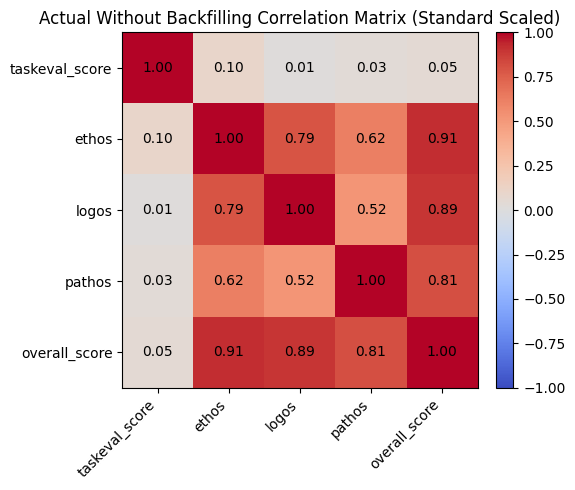

In [9]:
plot(score_actual, "Actual")

In [82]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

def flatten_data(data_list):
    rows = []
    for entry in data_list:
        env_value = entry.get('env')
        for country in entry.get('countries', []):
            row = {
                'env': env_value,
                'country': country
            }
            taskeval_key = f'{country}_taskeval_score'
            negoeval_key = f'{country}_negoeval_score'
            if taskeval_key in entry:
                row['taskeval_score'] = entry[taskeval_key]
            else:
                row['taskeval_score'] = np.nan
            
            if negoeval_key in entry:
                row['ethos'] = entry[negoeval_key].get('ethos', np.nan)
                row['logos'] = entry[negoeval_key].get('logos', np.nan)
                row['pathos'] = entry[negoeval_key].get('pathos', np.nan)
                row['overall_score'] = entry[negoeval_key].get('overall_score', np.nan)
            else:
                row['ethos'] = np.nan
                row['logos'] = np.nan
                row['pathos'] = np.nan
                row['overall_score'] = np.nan
            
            rows.append(row)
    
    df = pd.DataFrame(rows)
    return df

def preprocess_and_correlate(df, scale_method='standard'):

    numeric_cols = ['taskeval_score', 'ethos', 'logos', 'pathos', 'overall_score']
    # 去掉缺失值
    df_clean = df.dropna(subset=numeric_cols).copy()
    
    # 根据指定的方法进行数值列的缩放
    if scale_method == 'standard':
        scaler = StandardScaler()
    elif scale_method == 'minmax':
        from sklearn.preprocessing import MinMaxScaler
        scaler = MinMaxScaler()
    else:
        raise ValueError("scale_method only support 'standard' or 'minmax'")
    
    df_clean[numeric_cols] = scaler.fit_transform(df_clean[numeric_cols])
    corr_matrix = df_clean[numeric_cols].corr(method='pearson')
    return corr_matrix, df_clean

def plot_correlation_matrix(corr_df, title="Correlation Matrix"):
    plt.figure(figsize=(6, 5))
    im = plt.imshow(corr_df, vmin=-1, vmax=1)  # 默认配色，不做任何指定
    plt.title(title)
    plt.colorbar(im, fraction=0.046, pad=0.04)
    
    ticks = np.arange(len(corr_df.columns))
    plt.xticks(ticks, corr_df.columns, rotation=45, ha="right")
    plt.yticks(ticks, corr_df.columns)
    
    # 在每个cell里输出数值
    for i in range(len(corr_df.columns)):
        for j in range(len(corr_df.columns)):
            plt.text(j, i, f"{corr_df.iloc[i, j]:.2f}",
                     ha="center", va="center")
    
    plt.tight_layout()
    plt.show()

def plot_scatter_plots(df, numeric_cols):
    """
    针对 numeric_cols 中的所有成对组合，逐一绘制散点图。
    每个散点图单独生成一个 figure。
    """
    for i in range(len(numeric_cols)):
        for j in range(i + 1, len(numeric_cols)):
            col_x = numeric_cols[i]
            col_y = numeric_cols[j]
            plt.figure()  # 每一对变量独立生成一个 Figure
            plt.scatter(df[col_x], df[col_y])
            plt.xlabel(col_x)
            plt.ylabel(col_y)
            plt.title(f"Scatter Plot of {col_x} vs {col_y}")
            plt.show()

def plot(data_list, model):
    df = flatten_data(data_list)

    # 先做缩放和相关性分析
    corr_matrix, df_clean = preprocess_and_correlate(df, scale_method='minmax')

    # 打印前几行以确认数据预处理结果
    print(df_clean.head(), "\n")

    # 打印相关矩阵
    print("Correlation Matrix:")
    print(corr_matrix, "\n")

    # 绘制相关矩阵热力图
    plot_correlation_matrix(corr_matrix, title=f"{model.capitalize()} Correlation Matrix (MinMax Scaled)")

    # 增加散点图查看指标间关系
    numeric_cols = ['taskeval_score', 'ethos', 'logos', 'pathos', 'overall_score']
    plot_scatter_plots(df_clean, numeric_cols)


                          env  country  taskeval_score  ethos  logos  pathos  \
0  01JN071FEATXC1XA1EYB5S0RAK   Turkey        0.381135  0.750  0.625   0.625   
1  01JN071FEATXC1XA1EYB5S0RAK  Austria        0.698918  0.625  0.500   0.750   
2  01JN071ESYEHVCQTJCHC094DWC  Austria        0.380635  0.875  1.000   0.750   
3  01JN071ESYEHVCQTJCHC094DWC    Italy        0.282992  0.750  0.875   0.625   
4  01JN071F5KS3AQRVFKCCQ99W9H   Turkey        0.388494  0.500  0.625   0.375   

   overall_score  
0       0.695652  
1       0.652174  
2       0.913043  
3       0.782609  
4       0.521739   

Correlation Matrix:
                taskeval_score     ethos     logos    pathos  overall_score
taskeval_score        1.000000  0.043606 -0.062287 -0.000664      -0.012657
ethos                 0.043606  1.000000  0.770610  0.593372       0.901252
logos                -0.062287  0.770610  1.000000  0.495579       0.885736
pathos               -0.000664  0.593372  0.495579  1.000000       0.803733
ove

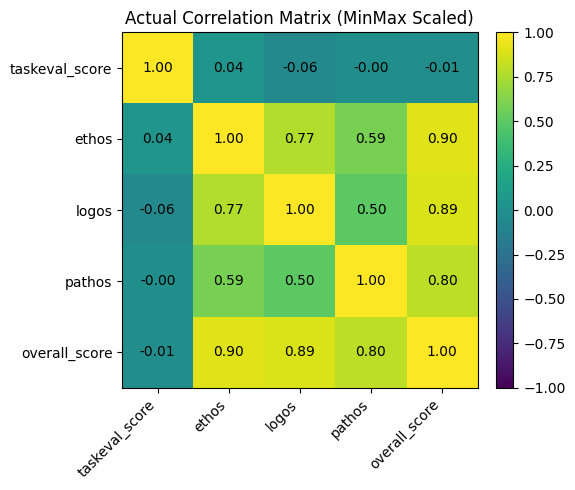

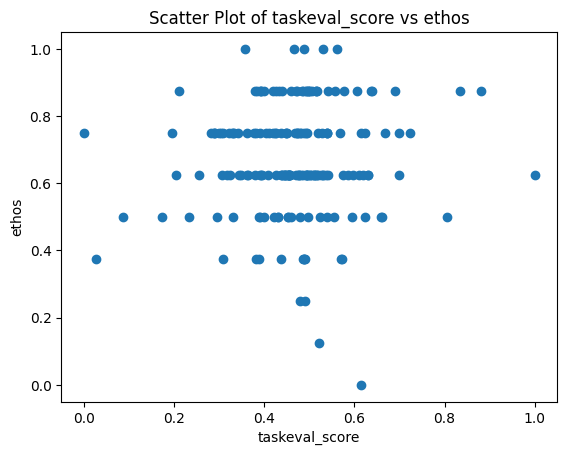

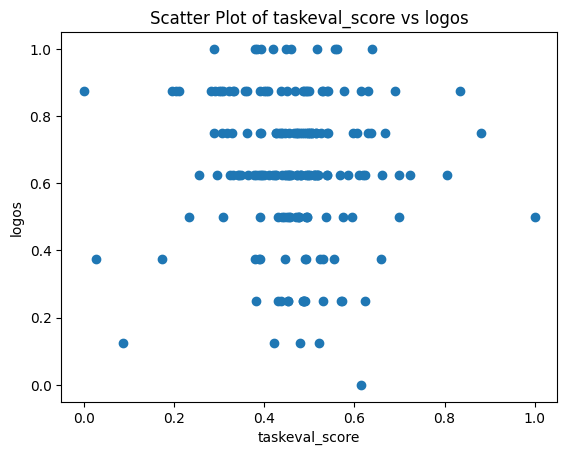

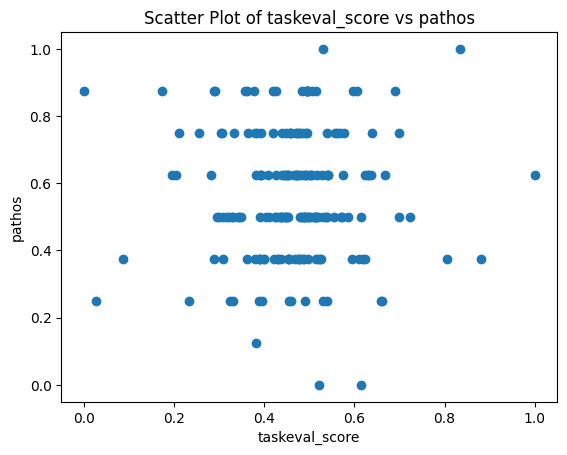

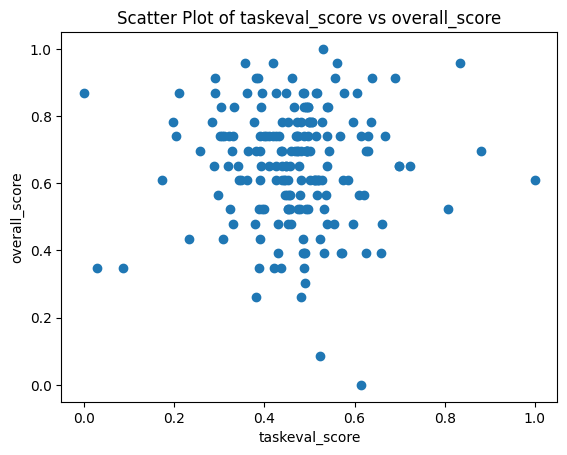

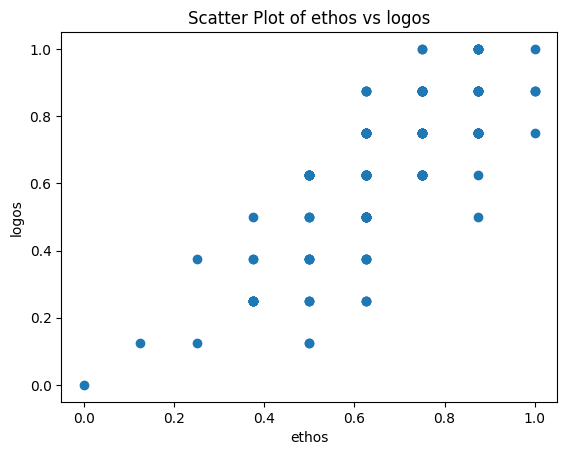

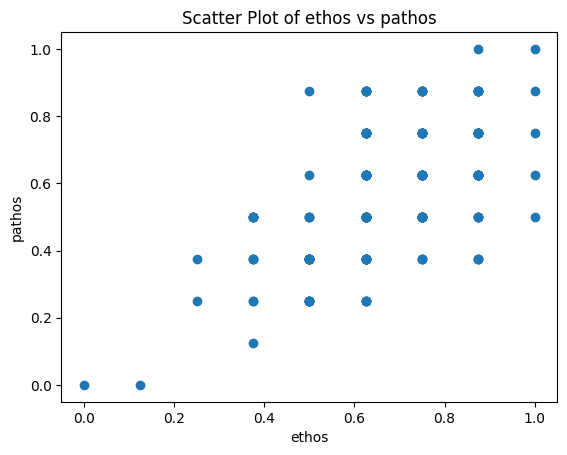

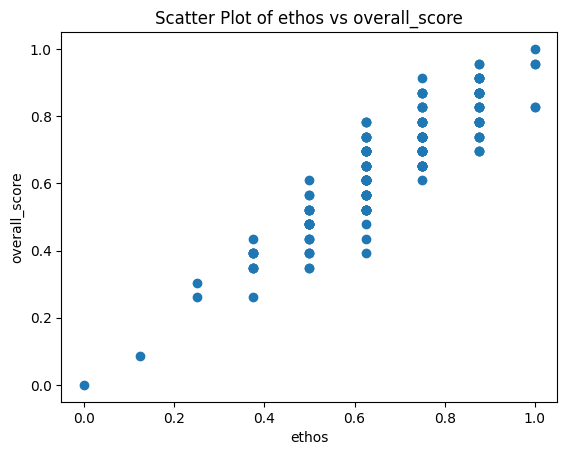

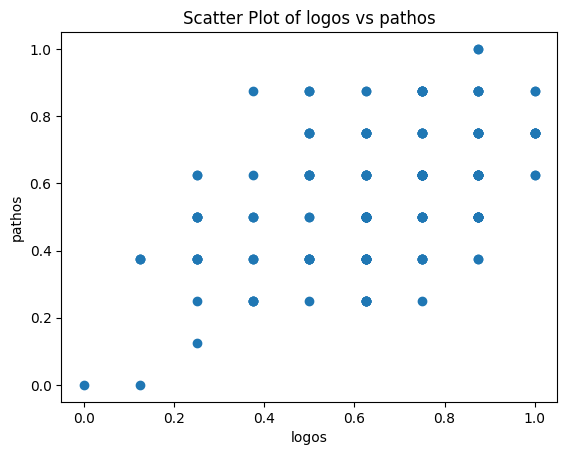

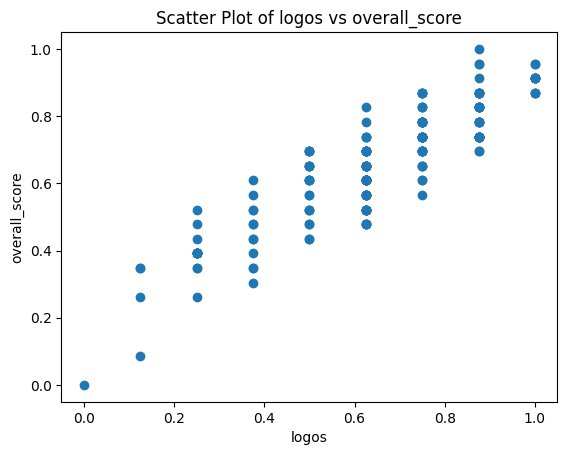

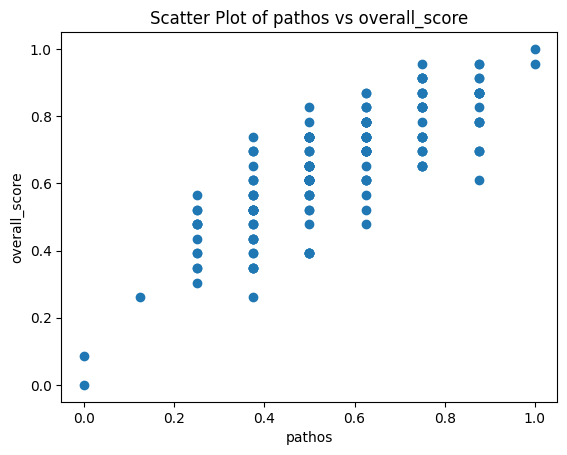

In [83]:
plot(score_actual, "Actual")

### Explore Intent Prediction with Actual

In [84]:
import json

In [85]:
with open("actual_movement.json", "r") as f:
    data = json.load(f)
    
countries_list = ['Austria', 'England', 'France', 'Germany', 'Italy', 'Russia', 'Turkey']

FileNotFoundError: [Errno 2] No such file or directory: 'actual_movement.json'

In [86]:
data[0]

NameError: name 'data' is not defined

In [ ]:
for i in data:
